### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Load Dataset


In [3]:
df = pd.read_csv("C:/Users/adni/Downloads/Mall_Customers.csv")

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Check Missing Values

In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
X = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

In [10]:
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


### Standardize Features

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [13]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_scaled)

In [14]:
X_pca.shape

(200, 2)

### Variance Explained

In [15]:
pca.explained_variance_ratio_

array([0.44266167, 0.33308378])

### Total Variance Explained

In [16]:
print(
    pca.explained_variance_ratio_.sum()
)

0.7757454566976747


### PCA Dataframe

In [17]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)

pca_df.head()

,PC1,PC2
0,-0.615720,-1.763481
1,-1.665793,-1.820747
2,0.337862,-1.674799
3,-1.456573,-1.772430
4,-0.038465,-1.662740


### PCA Visualization

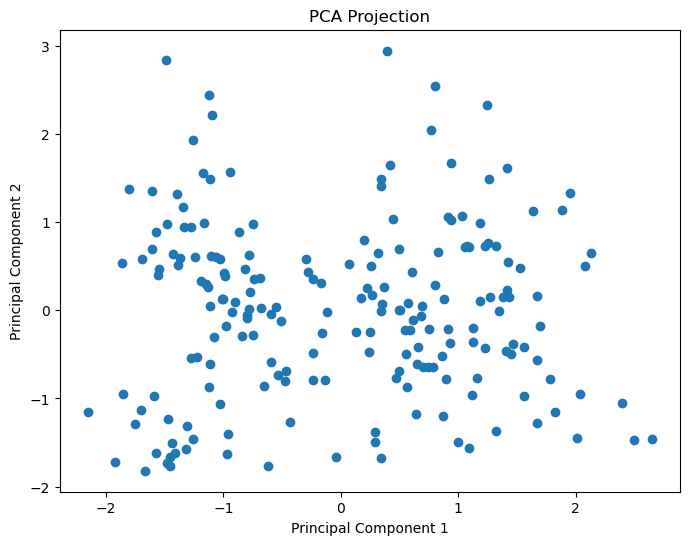

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"]
)

plt.title("PCA Projection")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

### Scree plot

In [19]:
pca_all = PCA()

pca_all.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


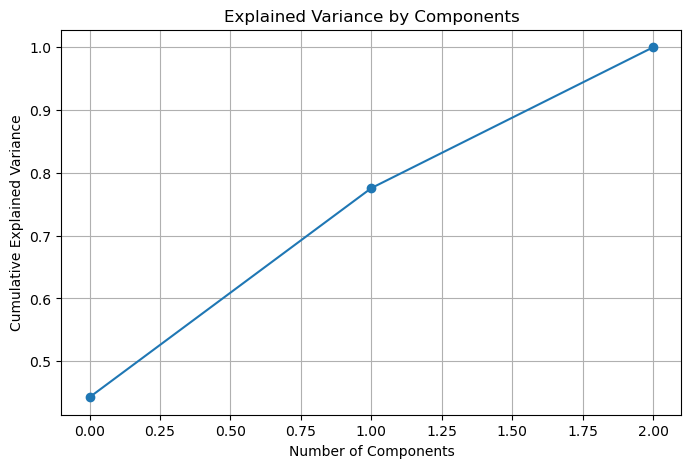

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(
        pca_all.explained_variance_ratio_
    ),
    marker="o"
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("Explained Variance by Components")

plt.grid()

plt.show()